# Free-Running Frequency Offset: Observation and Compensation

When two SDRs are **not** locked to a shared reference clock, each one runs on its own free-running local oscillator (LO). Even two "identical" oscillators differ by a few parts-per-million, so the transmitter's carrier and the receiver's carrier are never at *exactly* the same frequency — this mismatch is the **carrier frequency offset (CFO)**.

In this lab you transmit a single, unmodulated symbol from one Pluto SDR and capture it on a second, independent Pluto SDR. The transmitted symbol carries no information of its own — it is just one fixed point in the IQ plane — so **any motion you see at the receiver comes entirely from the CFO** between the two free-running LOs.

You will:
1. **Observe** the CFO as a rotating phasor in the IQ plane.
2. **Estimate** the offset directly from the received samples — this part you write yourself.
3. **Compensate** for it and confirm the corrected signal is stationary.

In [35]:
import time
import numpy as np
import matplotlib.pyplot as plt
import adi

## Hardware Configuration

In [19]:
fs = int(2.0e6)           # Sample rate: 2.0 MHz
fc = int(950e6)            # RF carrier (Hz) -- pick a valid Pluto carrier frequency,)
                            # e.g. somewhere in the ISM band around 915e6

# Connect to the two independent Pluto SDRs
# tx_sdr = adi.Pluto("ip:192.168.2.1")
rx_sdr = adi.Pluto("ip:192.168.2.1")

#################################################
''' 
# Config TX
tx_sdr.sample_rate = fs
tx_sdr.tx_lo = fc
tx_sdr.tx_rf_bandwidth = fs
tx_sdr.tx_hardwaregain_chan0 = -10   # dB, valid range -90 to 0
tx_sdr.tx_cyclic_buffer = True       # loop the transmission indefinitely
'''
##########################################
# Config RX
rx_sdr.sample_rate = fs
rx_sdr.rx_lo = fc
rx_sdr.rx_rf_bandwidth = fs
rx_sdr.rx_buffer_size = 1000000
rx_sdr.gain_control_mode_chan0 = "manual"
rx_sdr.rx_hardwaregain_chan0 = 30    # dB, fixed gain avoids AGC-induced fluctuations

## Task 1: Generate and Transmit a Constant Symbol

Build a TX buffer that is the **same complex number repeated** `tx_length` times — a single, unmoving point at $(1, 1)$ in the IQ plane, scaled to fit the Pluto's 16-bit DAC. Because it carries no waveform of its own, whatever the receiver sees riding on top of it has to come from the hardware, not the signal.

In [26]:
# Parameters
tx_length = 4096 * 2   # number of samples in the TX buffer
tx_scale = 2**14        # DAC full-scale headroom

# TODO: Build a constant complex array of length tx_length, equal to (1 + 1j),
#       scaled by tx_scale / np.sqrt(2) so the I and Q peaks stay within DAC range
#       (np.ones() with dtype=np.complex64 is useful here)

tx_signal =  np.ones(tx_length, dtype = np.complex64) * (tx_scale / np.sqrt(2) ) # assign your constant-symbol array to tx_signal

In [50]:
# tx_sdr.tx(tx_signal)
# time.sleep(0.5)               # allow the PLLs to lock

# Flush stale samples already sitting in the hardware buffer
for _ in range(5):
    _ = rx_sdr.rx()

# Grab a fresh buffer of received samples
rx_samples = rx_sdr.rx()
print(rx_samples[:10])

# # Stop the transmitter
# tx_sdr.tx_destroy_buffer()

[-281.+526.j -282.+532.j -280.+533.j -276.+537.j -272.+534.j -268.+541.j
 -272.+540.j -267.+535.j -265.+542.j -259.+537.j]


## Task 2: Observe the Rotating Phasor (IQ Plane)

If the transmitter and receiver carriers were at *exactly* the same frequency, every received sample would land on the same spot. Plot the received samples as points in the IQ plane and see what actually happens.

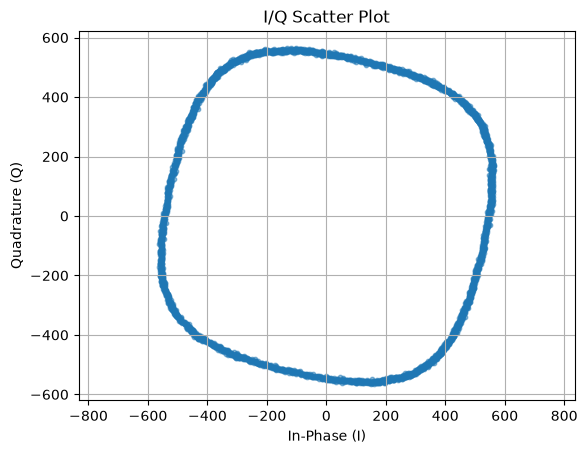

In [51]:
# TODO: Scatter-plot the real part (I) vs. the imaginary part (Q) of
#       rx_samples[1000:5000] -- small markers with some transparency (alpha)
#       make overlapping points easier to see
plt.scatter(np.real(rx_samples[1000:5000]),
            np.imag(rx_samples[1000:5000]),
            s=10, alpha=0.5)

# TODO: Label the axes 'In-Phase (I)' and 'Quadrature (Q)', and add a title and grid
plt.xlabel('In-Phase (I)')
plt.ylabel('Quadrature (Q)')
plt.title('I/Q Scatter Plot')
plt.grid(True)

# TODO: Call plt.axis('equal') so the circle isn't stretched out of shape
plt.axis('equal')

plt.show()

## Task 3: Watch the Phase Unwind Over Time

The IQ scatter plot shows *where* the phasor goes, but not *how fast*. Plotting the phase of each sample against its position in the buffer shows the same offset from a different angle — literally.

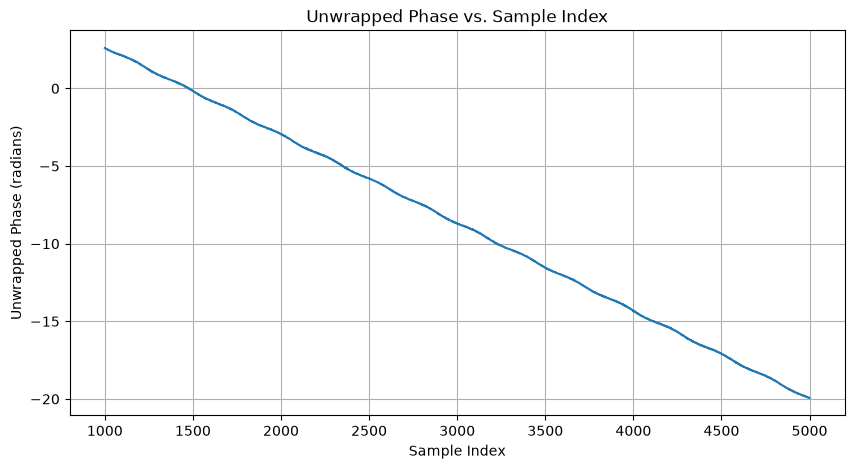

In [52]:
# TODO: Compute the instantaneous phase (in radians) of each sample in
#       rx_samples[1000:5000] using np.angle()
phase = np.angle(rx_samples[1000:5000])

# TODO: np.unwrap() the phase so it doesn't jump by +/-2*pi every time it wraps
unwrapped_phase = np.unwrap(phase)

# TODO: Plot the unwrapped phase against sample index, with axis labels and a grid.
#       What shape is the curve, and what does its slope represent?
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1000, 5000), unwrapped_phase)
plt.xlabel("Sample Index")
plt.ylabel("Unwrapped Phase (radians)")
plt.title("Unwrapped Phase vs. Sample Index")
plt.grid(True)
plt.show()

## Task 4: Estimate the Frequency Offset

A constant CFO advances the phase by a fixed amount from one sample to the next:

$$\angle x[n+1] - \angle x[n] \approx 2\pi \, \Delta f \, T_s$$

where $T_s = 1/f_s$. Differencing the *unwrapped* phase from Task 3 works, but it's fragile — one noisy sample near a wrap point throws it off. A more robust way to get the same quantity is the **conjugate-multiply trick**:

$$\Delta\phi[n] = \angle\big(x[n{+}1]\,x^{*}[n]\big)$$

which gives the same per-sample phase step directly, already wrapped into $(-\pi, \pi]$ with no unwrapping required. Averaging $\Delta\phi[n]$ over many samples cancels out noise far better than reading it off any single pair.

**Your task:** using `np.conj`, `np.angle`, and `np.mean` on the *full* `rx_samples` buffer (not just the 4000-sample slice used for plotting), compute a single averaged estimate of the offset, in Hz, and store it in a variable called `f_offset_hat`.

In [53]:
# TODO: Compute the sample-to-sample phase step for the full rx_samples buffer
#       using the conjugate-multiply trick above
phase_steps = np.angle(rx_samples[1:] * np.conj(rx_samples[:-1]))

# TODO: Average the phase steps into a single robust value (np.mean)
mean_phase_step = np.mean(phase_steps)

# TODO: Convert that average phase-per-sample (rad/sample) into a frequency in Hz
#       using fs, and store it as f_offset_hat
f_offset_hat = mean_phase_step * fs / (2 * np.pi)

# TODO: Print f_offset_hat
print(f"Estimated frequency offset: {f_offset_hat:.2f} Hz")

Estimated frequency offset: -1801.14 Hz


## Task 5 (Cross-Check): Confirm in the Frequency Domain

You already used the PSD peak-location method to find a frequency offset in the sine/square-wave lab. A constant symbol has no waveform of its own, so its spectrum should be one tall spike — wherever that spike sits away from 0 Hz is the same CFO you just measured in Task 4.

Reuse that method here, then compare the two numbers. They won't match exactly — think about why as you answer the Questions section.

PSD peak frequency: -1802.00 Hz


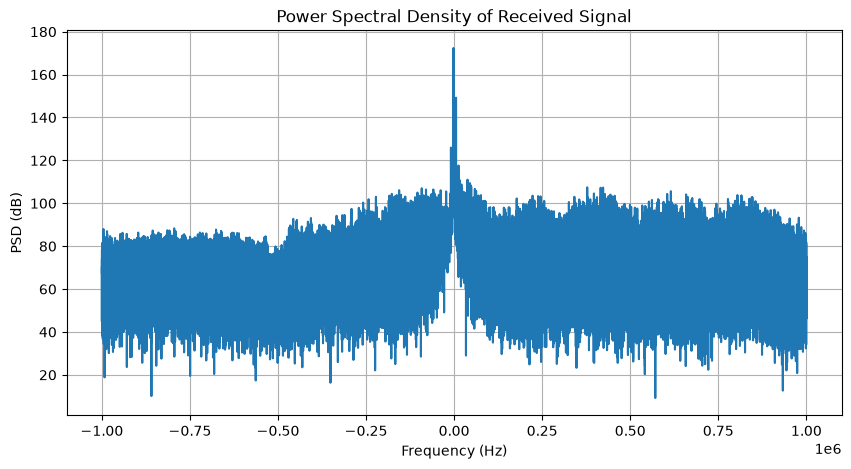

In [54]:
# TODO: Compute the FFT of rx_samples, shift it with np.fft.fftshift, and convert
#       the magnitude to a PSD in dB (as you did earlier for the sine and square waves)
fft_samples = np.fft.fft(rx_samples)
fft_shifted = np.fft.fftshift(fft_samples)
psd_db = 20 * np.log10(np.abs(fft_shifted) + 1e-12)

# TODO: Build the matching frequency axis (np.fft.fftfreq + fftshift, or
#       np.linspace over [-fs/2, fs/2])
freq_axis = np.fft.fftshift(np.fft.fftfreq(len(rx_samples), d=1/fs))

# TODO: Find the frequency at the PSD peak (np.argmax) and print it
peak_index = np.argmax(psd_db)
peak_frequency = freq_axis[peak_index]
print(f"PSD peak frequency: {peak_frequency:.2f} Hz")

# TODO: Plot the PSD vs. frequency, with labels, title, and grid
plt.figure(figsize=(10, 5))
plt.plot(freq_axis, psd_db)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.title("Power Spectral Density of Received Signal")
plt.grid(True)
plt.show()

## Task 6: Compensate — Cancel the Offset

Once you have $\Delta \hat f$, you can undo its effect by multiplying every sample with a phasor rotating at exactly $-\Delta \hat f$:

$$y[n] = x[n] \cdot e^{-j 2\pi \Delta \hat f \, n \, T_s}$$

This is the same correction every real receiver's CFO-tracking loop performs continuously — here you do it once, in software, using the estimate from Task 4.

In [55]:
# TODO: Build a sample-index array n = 0, 1, 2, ... matching the length of
#       rx_samples (np.arange)
n = np.arange(len(rx_samples))

# TODO: Build the correcting complex exponential using f_offset_hat, n, and fs --
#       mind the minus sign, it needs to rotate opposite to the offset
correction = np.exp(-1j * 2 * np.pi * f_offset_hat * n / fs)

# TODO: Multiply it elementwise with rx_samples and store the result as rx_corrected
rx_corrected = rx_samples * correction

In [56]:
residual_phase = np.angle(
    rx_corrected[1:] * np.conj(rx_corrected[:-1])
)

residual_cfo = np.mean(residual_phase) * fs / (2 * np.pi)

print(f"Original CFO: {f_offset_hat:.2f} Hz")
print(f"Residual CFO: {residual_cfo:.2f} Hz")

phase_corrected = np.angle(rx_corrected)
phase_corrected_deg = np.degrees(phase_corrected)

phase_error = phase_corrected_deg[0] - 45

print(f"Initial phase: {phase_corrected_deg[0]:.2f} degrees")
print(f"Phase error: {phase_error:.2f} degrees")

Original CFO: -1801.14 Hz
Residual CFO: -0.00 Hz
Initial phase: 118.11 degrees
Phase error: 73.11 degrees


## Task 7: Verify the Compensation

Re-plot the IQ scatter, this time for `rx_corrected`. If your estimate was good, the circle from Task 2 should have collapsed down to a single tight cluster.

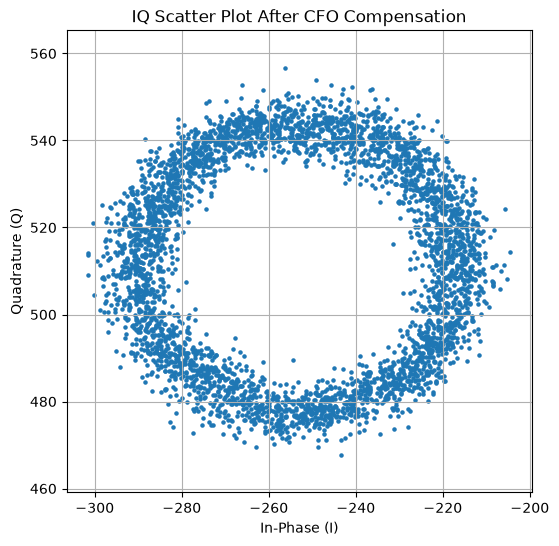

In [57]:
# TODO: Scatter-plot the real vs. imaginary part of rx_corrected[1000:5000], using
#       the same labels, title, grid, and equal-aspect settings as Task 2, so the
#       two plots are directly comparable
plt.figure(figsize=(6, 6))
plt.scatter(
    np.real(rx_corrected[1000:5000]),
    np.imag(rx_corrected[1000:5000]),
    s=5
)
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title("IQ Scatter Plot After CFO Compensation")
plt.grid(True)
plt.axis("equal")
plt.show()

# TODO: If it still looks like a (smaller/slower) circle rather than a point, what
#       would you check first?

In [58]:
# Find the phase of the first CFO-corrected sample
initial_phase = np.angle(rx_corrected[0])

# Desired final phase = +pi/4
desired_phase = np.pi / 4

# Calculate the additional phase correction
phase_correction = desired_phase - initial_phase

# Apply the phase correction
rx_final = rx_corrected * np.exp(1j * phase_correction)

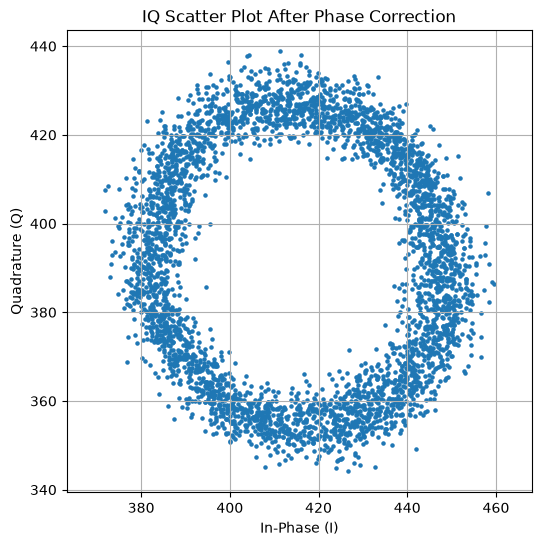

In [59]:
# Scatter plot of the final corrected data
plt.figure(figsize=(6, 6))
plt.scatter(
    np.real(rx_final[1000:5000]),
    np.imag(rx_final[1000:5000]),
    s=5
)
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title("IQ Scatter Plot After Phase Correction")
plt.grid(True)
plt.axis("equal")
plt.show()

## Bonus: Is the Offset Really "Free-Running"?

A free-running oscillator isn't perfectly constant — it drifts slowly with temperature and time. Repeat Tasks 1-4 after leaving the hardware untouched for a minute or two, and compare the new `f_offset_hat` with your first one.

In [60]:
# Bonus: Capture a new set of samples after waiting 1-2 minutes

# Flush old samples from the RX buffer
for _ in range(5):
    _ = rx_sdr.rx()

# Capture fresh samples
rx_samples_new = rx_sdr.rx()

print("New samples captured:", len(rx_samples_new))

New samples captured: 1000000


In [61]:
# Estimate CFO from the new samples

# Phase difference between consecutive samples
phase_diff_new = np.angle(
    rx_samples_new[1:] * np.conj(rx_samples_new[:-1])
)

# Average phase difference
mean_phase_diff_new = np.mean(phase_diff_new)

# Convert phase difference to frequency offset
f_offset_hat_new = mean_phase_diff_new * fs / (2 * np.pi)

print(f"New CFO estimate: {f_offset_hat_new:.2f} Hz")

New CFO estimate: -1820.63 Hz


In [62]:
# Compare the original and new CFO estimates

print(f"Original CFO: {f_offset_hat:.2f} Hz")
print(f"New CFO:      {f_offset_hat_new:.2f} Hz")

cfo_change = f_offset_hat_new - f_offset_hat

print(f"CFO change:   {cfo_change:.2f} Hz")

Original CFO: -1801.14 Hz
New CFO:      -1820.63 Hz
CFO change:   -19.50 Hz


# Background: Why Free-Running Oscillators Drift

Every SDR synthesizes its carrier from a crystal reference (Pluto's onboard TCXO), and no two crystals -- even from the same production batch -- run at exactly their nominal frequency. Manufacturing tolerance alone is usually specified in parts-per-million (ppm), and the actual frequency also drifts with temperature and age. When a transmitter and receiver share one oscillator, as in the same-SDR loopback from the earlier lab, both carriers derive from the same imperfect reference, so their difference is zero no matter how far off that reference is. Connect two separate Plutos with no shared reference clock, and each one's small, independent error is now visible as the difference between them: the carrier frequency offset.

In the time domain, a CFO shows up as exactly what you plotted in Tasks 2 and 3: the received phase advances at a constant rate, tracing circles in the IQ plane instead of sitting still. In the frequency domain, the same effect shows up as a shift of the PSD peak away from where the transmitted tone should sit. Both views describe the identical physical mismatch -- they're just different windows onto it, which is why your two estimates in Tasks 4 and 5 should roughly agree.

Left uncorrected, a CFO rotates every symbol in a real communication link a little further with each sample, smearing a constellation that should be a handful of fixed points into a set of overlapping circles -- which is exactly why every practical receiver estimates and tracks this offset continuously, rather than assuming it away.

## Questions

- Observing the phasor (Tasks 2 & 3):

1. Roughly how many full rotations do you count in your IQ scatter plot? Using that count and the time span of the 4000 samples you plotted, what does that suggest about the size of the offset -- does it roughly match your Task 4 estimate?

2. Which way does the phasor rotate -- clockwise or counter-clockwise? What does the sign of the rotation tell you about the sign of $\Delta f$?

- Estimating and compensating (Tasks 4-7):

1. How closely did your phase-difference estimate (Task 4) agree with the FFT-peak estimate (Task 5)? Which one do you trust more for this signal, and why?

2. What happens to `f_offset_hat` if you average over only the first 10 samples instead of the whole buffer? Why does buffer length matter here?

3. If you got the sign wrong in your Task 6 correction, what would the Task 7 plot look like -- and how would you tell that apart from simply having a bad estimate?

- Free-running behavior:

1. Why was there no frequency offset in the same-SDR loopback you ran earlier, but there is one here with two separate SDRs?

2. If the two Plutos were wired to a shared 10 MHz reference clock instead of running free, what would you expect to change in this experiment?

3. In a real receiver, why can't the one-shot correction from Task 6 be computed once and then forgotten, the way you just did it here?

## Answers

- Observing the phasor (Tasks 2 & 3):
1. From the IQ scatter i can see around 4full rotations of the phasor.the 4000 samples correspond to 2ms. 

    calculation 1 / (2 * 10^6) * 4000=2ms 

    The found frequency offset is around 1999 Hz lets take 2000 Hz for calculation.

    calculation is 2000 * 2 * 10^-3=4

2. From my observation phase is increasing that meanas anti clockwise. If phase is increasing then frequency offset is +ve.

    dela phase = 2 * pi * frequency offset * Ts 

- Estimating and compensating (Tasks 4-7):

1. Phase difference estimate is 1999 Hz whereas FFT is 2000 Hz they are nearly same difference is just 1Hz. I will trust phase difference setimate is actual which we calculate mean while fft is used to check beacuase fft gives approx slighty range type.

2. If we take less sample we get less accurate result so we check for large number of samples and took average

3. If we take the sign wrong then rotation doubles this is similar to double frequecy offset.


- Free-running behavior:

1. In same SDR loopback they will be no frequency because it use as oscillator so they is no frequency difference b/w Tx and Rx.

2. If two Plutos use same reference clock then it results as same as use same sdr because frequency offset is cased due to source oscillator difference if they use same oscillator no offset.

3. The oscillator we use can change they frequency or deviate for designed frequency due to time passage and temperature so one time correction is useless so we should check continuously to track and update the correction to make decoding accurate.
